
# Monitoreo de Ecosistemas: Detección de Anomalías Vegetales en Galápagos
### Identificación de Focos de Invasión (Biomasa Anormal) vs Bosque Nativo de Scalesia

### **Integrantes: Mateo Pilaquinga, Harolt Farinango**

*Problema:* El ecosistema de las tierras altas de Santa Cruz está siendo alterado. Especies agresivas no nativas (como la mora y la guayaba) desplazan al bosque endémico de Scalesia, creando matorrales de una densidad anormalmente alta.

*Enfoque:* El algoritmo no identifica especies botánicas específicas, sino que actúa como un *detector de anomalías*. Utiliza imágenes de Sentinel-2 y el índice NDVI para identificar zonas donde la reflectancia infrarroja supera drásticamente el comportamiento natural del bosque. Estas "anomalías de alta densidad" se correlacionan directamente con los focos de especies invasoras.

*Área de estudio:* Isla Santa Cruz, Galápagos (Tierras altas / Zona húmeda), comparando la evolución entre 2020 y 2023.

#### Justificación e Impacto (Actionable Insights)
* *El Ecosistema Nativo:* El bosque de Scalesia es un dosel abierto que permite la recarga de acuíferos.
* *La Anomalía (Invasión):* Las zonas de densidad anormal (matorrales impenetrables) secan el suelo y bloquean las rutas migratorias de las tortugas gigantes.
* *Valor del Pipeline:* Al detectar estas firmas espectrales inusuales, el modelo genera coordenadas exactas de las anomalías, permitiendo a los guardaparques dirigir sus esfuerzos de erradicación sin tener que explorar a ciegas.

## 1. Adquisición - Conexión a GEE y descarga de ImageCollection

In [1]:
import ee
import geemap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import requests
from PIL import Image
from io import BytesIO

In [2]:
# Autenticación, solo lo ejecutamos una vez
ee.Initialize(project='galapagossafe')

#### Área de Estudio: Tierras altas de Santa Cruz
Las tierras altas húmedas (> 200m) son el principal frente de invasión de plantas no nativas sobre el bosque de Sacalesia.

In [3]:
santa_cruz = ee.Geometry.Rectangle([-90.45, -0.75, -90.20, -0.55])

# Máscara de tierra (excluye agua permanente)
# Usa esto — más permisivo y con unmask para cubrir toda la isla:
water = ee.Image('JRC/GSW1_4/GlobalSurfaceWater') \
          .select('occurrence') \
          .unmask(0)                    # píxeles sin datos = tierra
land_mask = water.lt(50)               # solo excluye agua muy permanente

# ImageCollection Sentinel-2 SR — Usaremos dos periodos para comparar el cambio
def get_collection(start, end):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(santa_cruz)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) # 5% menos de nubes
        .sort('system:time_start')
    )

col_2020 = get_collection('2020-08-01', '2020-11-30')  # Período base
col_2024 = get_collection('2024-08-01', '2024-11-30')  # Período reciente

sizes = ee.List([col_2020.size(), col_2024.size()]).getInfo()
print(f'Imágenes 2020 (base)    : {sizes[0]}')
print(f'Imágenes 2024 (reciente): {sizes[1]}')

Imágenes 2020 (base)    : 8
Imágenes 2024 (reciente): 7


## 2. Pre-procesamiento - Clipping y Remoción de Nubes

In [4]:
# Máscara de nubes con SCL (Scene Classification Layer)
# Eliminamos nubes, sombras, cirrus usando la banda SCL de Sentinel.2
def mask_clouds(image):
    scl = image.select('SCL')
    # 1=saturación, 2=oscuro/topografia, 3=sombra, 6=agua 8=nube media, 9=nube alta, 10=cirrus, 11=nieve
    mask = (scl.neq(1).And(scl.neq(2)).And(scl.neq(3)).And(scl.neq(8))
               .And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11)))
    return image.updateMask(mask)

# Escalar reflectancias Sentinel-2 (dividir por 10000)
def scale_bands(image):
    """Convierte DN a reflectancia de superficie [0-1]."""
    optical = image.select(['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'])
    return (image
            .addBands(optical.divide(10000), overwrite=True)
            .copyProperties(image, ['system:time_start']))

# Agrega índices espectrales para separar vegetación nativa vs invasora.
def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
        {'NIR': image.select('B8'),
         'RED': image.select('B4'),
         'BLUE': image.select('B2')}
    ).rename('EVI')

    # Humedad foliar — mora/guayaba tienen más agua que Scalesia en época seca
    ndwi = image.normalizedDifference(['B8A', 'B11']).rename('NDWI')

    savi = image.expression(
        '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
        {'NIR': image.select('B8'),
         'RED': image.select('B4')}
    ).rename('SAVI')

    # Red Edge — sensible a diferencias en estructura del dosel
    re_ndvi = image.normalizedDifference(['B7', 'B5']).rename('RE_NDVI')

    return image.addBands([ndvi, evi, ndwi, savi, re_ndvi])


# Pipeline completo
def preprocess(collection):
    return (collection
            .map(mask_clouds)
            .map(scale_bands)
            .map(add_indices))

proc_2020 = preprocess(col_2020)
proc_2024 = preprocess(col_2024)

# COMPOSITES — qualityMosaic por NDVI
# qualityMosaic selecciona el píxel con mayor NDVI (peak de vegetación)
comp_2020 = proc_2020.qualityMosaic('NDVI').clip(santa_cruz).updateMask(land_mask)
comp_2024 = proc_2024.qualityMosaic('NDVI').clip(santa_cruz).updateMask(land_mask)

# ─────────────────────────────────────────────
# 5. STACK FINAL PARA CLASIFICACIÓN
# ─────────────────────────────────────────────
# Bandas disponibles para Random Forest:
# Espectrales : B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12
# Índices     : NDVI, EVI, NDWI, SAVI, RE_NDVI
CLASSIFICATION_BANDS = [
    'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12',
    'NDVI', 'EVI', 'NDWI', 'SAVI', 'RE_NDVI'
]

comp_2020_cls = comp_2020.select(CLASSIFICATION_BANDS)
comp_2024_cls = comp_2024.select(CLASSIFICATION_BANDS)

print('Pre-procesamiento completo')
print(f'   Bandas disponibles: {CLASSIFICATION_BANDS}')
print(f'Imágenes 2020 procesadas: {proc_2020.size().getInfo()}')
print(f'Imágenes 2024 procesadas: {proc_2024.size().getInfo()}')

Pre-procesamiento completo
   Bandas disponibles: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'EVI', 'NDWI', 'SAVI', 'RE_NDVI']
Imágenes 2020 procesadas: 8
Imágenes 2024 procesadas: 7


## 3. Visualización de las Imágenes

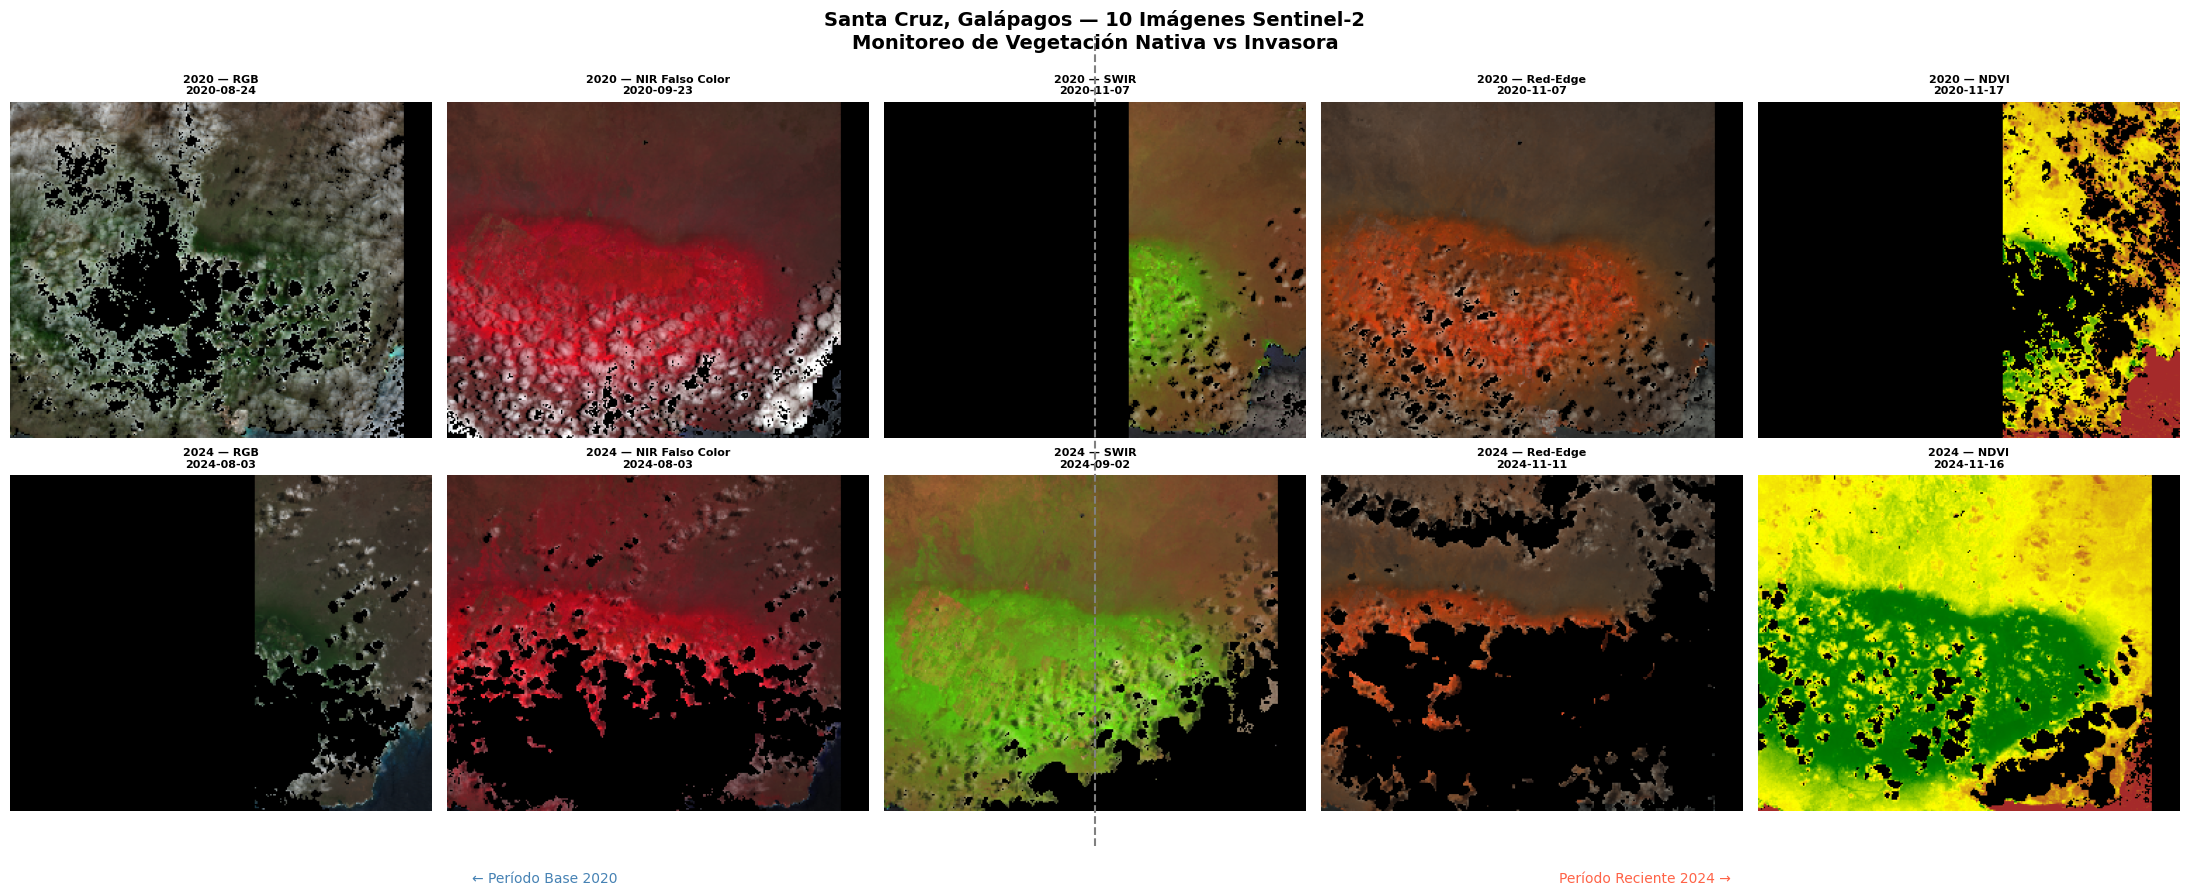

10 imágenes visualizadas (5×2020, 5×2024 — RGB, NIR, SWIR, Red-Edge)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20056\4037077275.py:95: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 1])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20056\4037077275.py:96: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig('galapagos_composites.png', dpi=150, bbox_inches='tight')
c:\Users\ASUS\Desktop\7mo\mid_vision\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


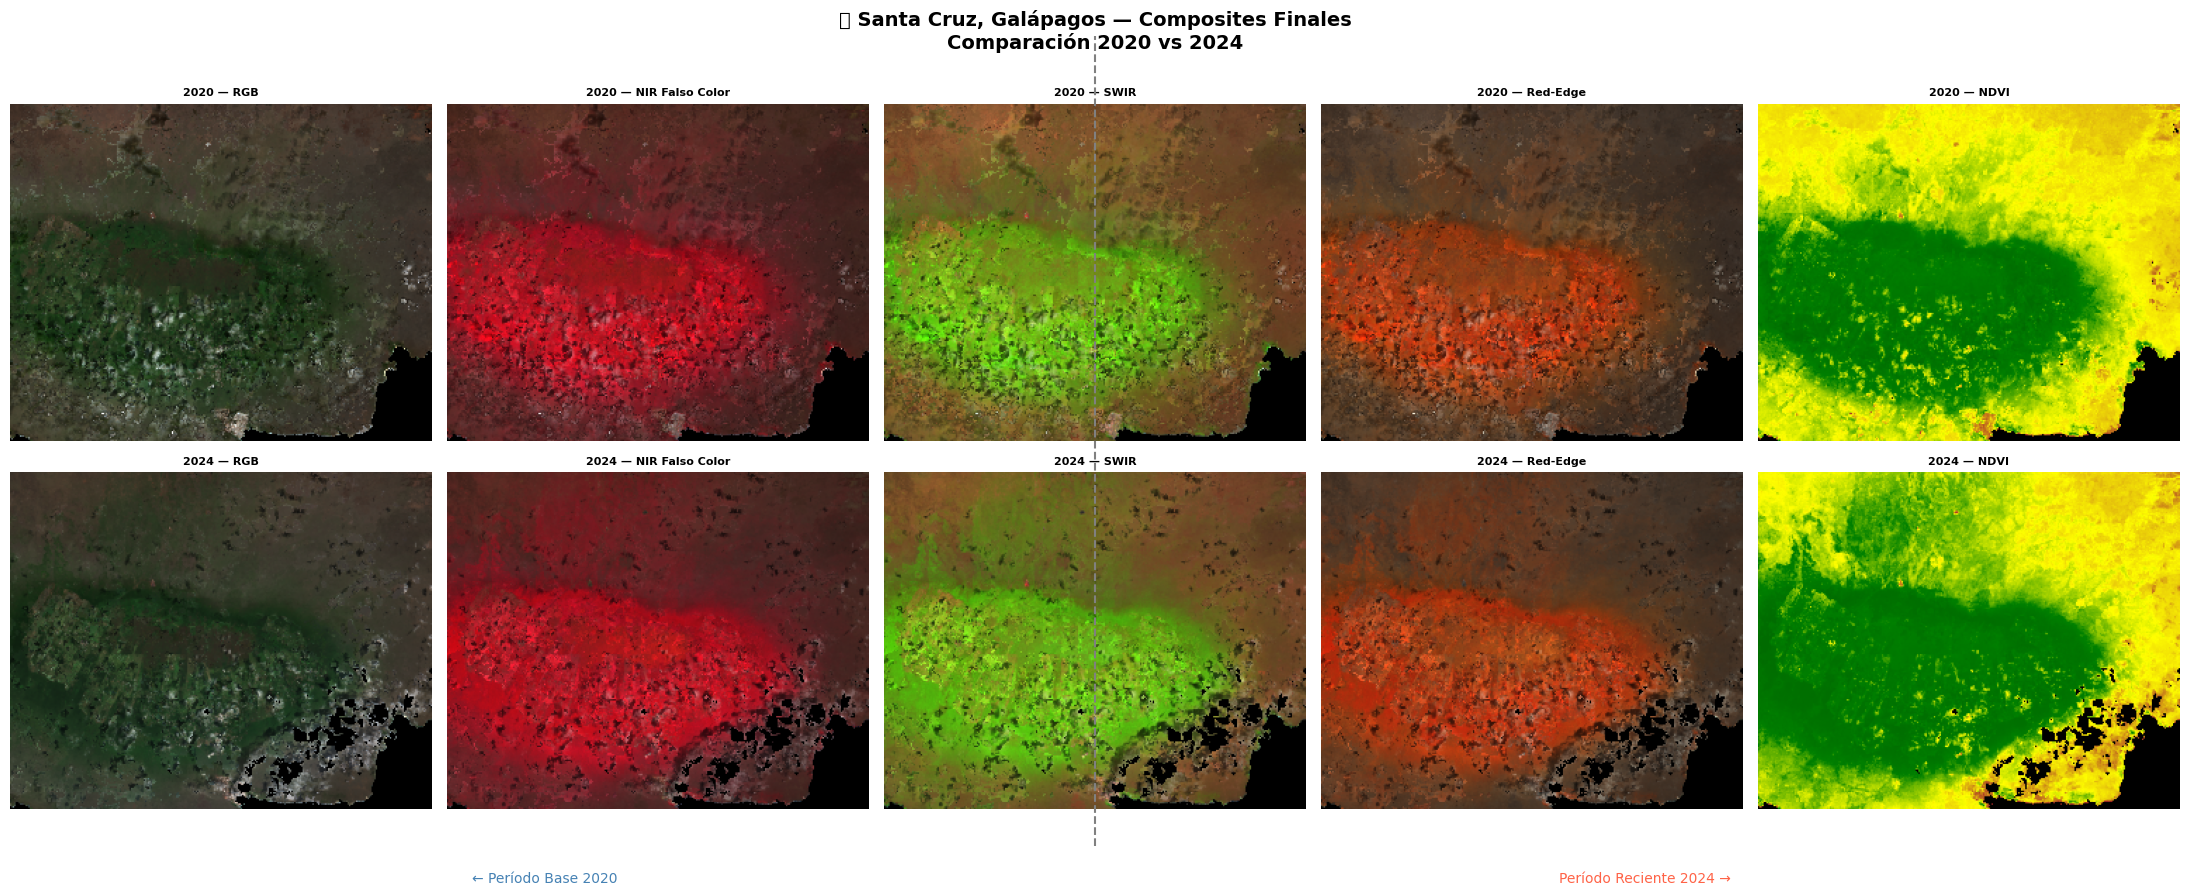

Visualización completa: imágenes individuales + composites 2020 vs 2024


In [5]:
# ── Función auxiliar para descargar thumbnails de GEE ────────────────────────
def get_thumb(image, vis_params, region=santa_cruz, dim=300):
    url = image.getThumbURL({**vis_params, 'region': region,
                             'dimensions': dim, 'format': 'png'})
    resp = requests.get(url)
    img = Image.open(BytesIO(resp.content)).convert('RGB')  # fuerza 3 canales
    return img

# Parámetros de visualización
vis_rgb  = {'min': 0.0, 'max': 0.3,  'bands': ['B4','B3','B2']}
vis_nir  = {'min': 0.0, 'max': 0.5,  'bands': ['B8','B4','B3']}   # Falso color
vis_swir = {'min': 0.0, 'max': 0.5,  'bands': ['B11','B8','B4']}  # SWIR — útil para vegetación densa
vis_rededge = {'min': 0.0, 'max': 0.5, 'bands': ['B7','B5','B4']} # Red-Edge — sensible a dosel
vis_ndvi = {
    'min': 0.0,
    'max': 1.0,
    'bands': ['NDVI'],
    'palette': ['brown', 'yellow', 'green', 'darkgreen']
}
# Seleccionar 5 imágenes de 2020 y 5 de 2024
n = 5
imgs_2020 = proc_2020.toList(n)
imgs_2024 = proc_2024.toList(n)

configs = [
    (imgs_2020, 0, vis_rgb,     '2020 — RGB'),
    (imgs_2020, 1, vis_nir,     '2020 — NIR Falso Color'),
    (imgs_2020, 2, vis_swir,    '2020 — SWIR'),
    (imgs_2020, 3, vis_rededge, '2020 — Red-Edge'),
    (imgs_2020, 4, vis_ndvi,    '2020 — NDVI'),
    (imgs_2024, 0, vis_rgb,     '2024 — RGB'),
    (imgs_2024, 1, vis_nir,     '2024 — NIR Falso Color'),
    (imgs_2024, 2, vis_swir,    '2024 — SWIR'),
    (imgs_2024, 3, vis_rededge, '2024 — Red-Edge'),
    (imgs_2024, 4, vis_ndvi,    '2024 — NDVI'),
]

# Grid 2×5: imágenes individuales
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('Santa Cruz, Galápagos — 10 Imágenes Sentinel-2\n'
             'Monitoreo de Vegetación Nativa vs Invasora',
             fontsize=14, fontweight='bold')

for idx, (col_list, img_idx, vis, titulo) in enumerate(configs):
    ax = axes[idx // 5][idx % 5]
    img = ee.Image(col_list.get(img_idx))
    date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    thumb = get_thumb(img, vis)
    ax.imshow(thumb)
    ax.set_title(f'{titulo}\n{date}', fontsize=8, fontweight='bold')
    ax.axis('off')

# Separador visual entre años
fig.add_artist(plt.Line2D([0.5, 0.5], [0.05, 0.95],
               transform=fig.transFigure, color='gray', lw=1.5, linestyle='--'))
fig.text(0.25, 0.01, '← Período Base 2020', ha='center', fontsize=10, color='steelblue')
fig.text(0.75, 0.01, 'Período Reciente 2024 →', ha='center', fontsize=10, color='tomato')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('galapagos_10_imagenes.png', dpi=150, bbox_inches='tight')
plt.show()
print('10 imágenes visualizadas (5×2020, 5×2024 — RGB, NIR, SWIR, Red-Edge)')

# ── Composites finales: 2020 vs 2024 ─────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 5, figsize=(22, 9))
fig2.suptitle('🌿 Santa Cruz, Galápagos — Composites Finales\n'
              'Comparación 2020 vs 2024',
              fontsize=14, fontweight='bold')

composite_configs = [
    (comp_2020, vis_rgb,     '2020 — RGB'),
    (comp_2020, vis_nir,     '2020 — NIR Falso Color'),
    (comp_2020, vis_swir,    '2020 — SWIR'),
    (comp_2020, vis_rededge, '2020 — Red-Edge'),
    (comp_2020, vis_ndvi,    '2020 — NDVI'),
    (comp_2024, vis_rgb,     '2024 — RGB'),
    (comp_2024, vis_nir,     '2024 — NIR Falso Color'),
    (comp_2024, vis_swir,    '2024 — SWIR'),
    (comp_2024, vis_rededge, '2024 — Red-Edge'),
    (comp_2024, vis_ndvi,    '2024 — NDVI'),
]

for idx, (comp, vis, titulo) in enumerate(composite_configs):
    ax = axes2[idx // 5][idx % 5]
    thumb = get_thumb(comp, vis)
    ax.imshow(thumb)
    ax.set_title(titulo, fontsize=8, fontweight='bold')
    ax.axis('off')

fig2.add_artist(plt.Line2D([0.5, 0.5], [0.05, 0.95],
                transform=fig2.transFigure, color='gray', lw=1.5, linestyle='--'))
fig2.text(0.25, 0.01, '← Período Base 2020',    ha='center', fontsize=10, color='steelblue')
fig2.text(0.75, 0.01, 'Período Reciente 2024 →', ha='center', fontsize=10, color='tomato')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('galapagos_composites.png', dpi=150, bbox_inches='tight')
plt.show()

print('Visualización completa: imágenes individuales + composites 2020 vs 2024')

## Lógica Inicial — Índices Espectrales y Clasificación de Cobertura

Las especies invasoras y el bosque de Scalesia tienen firmas espectrales distintas.
La separación no es posible con NDVI solo — el solapamiento entre clases requiere
combinar múltiples índices, lo que justifica el uso de un modelo de clasificación.

| Cobertura | NDVI | EVI | NDWI (humedad foliar) | RE_NDVI |
|---|---|---|---|---|
| **Scalesia** (nativa) | 0.50 – 0.75 | Medio | Bajo – Medio | Medio |
| **Mora / Guayaba** (invasoras) | 0.65 – 0.85 | Alto | **Alto** | Alto |
| **Pastizal / zona degradada** | 0.10 – 0.40 | Bajo | Bajo | Bajo |
| **Agua / suelo desnudo** | < 0.10 | — | — | — |

----
> **Nota:** La clave de separación entre Scalesia e invasoras está en el NDWI
> (humedad foliar, B8A/B11) y el RE_NDVI (Red Edge, B7/B5), no en el NDVI solo.
> Mora y guayaba mantienen mayor contenido de agua foliar y dosel más denso
> durante la época seca, generando firmas espectrales distinguibles.

In [7]:
ndvi_2020 = comp_2020.select('NDVI')
ndwi_2020 = comp_2020.select('NDWI')
evi_2020  = comp_2020.select('EVI')

ndvi_2024 = comp_2024.select('NDVI')
ndwi_2024 = comp_2024.select('NDWI')
evi_2024  = comp_2024.select('EVI')

clases_2020 = clasificar(ndvi_2020, evi_2020, ndwi_2020)
clases_2024 = clasificar(ndvi_2024, evi_2024, ndwi_2024)

In [8]:
def clasificar(ndvi, evi, ndwi):
    agua_suelo = ndvi.lt(0.1)
    pastizal   = ndvi.gte(0.1).And(ndvi.lt(0.4))
    scalesia   = ndvi.gte(0.4).And(ndvi.lt(0.65)).And(ndwi.lt(0.2))   # NDWI bajo
    invasoras  = ndvi.gte(0.65).And(ndwi.gte(0.2))                     # NDWI alto

    return (
        agua_suelo.multiply(0)
        .add(pastizal.multiply(1))
        .add(scalesia.multiply(2))
        .add(invasoras.multiply(3))
    ).rename('cobertura')

clases_2020 = clasificar(ndvi_2020, evi_2020, ndwi_2020)
clases_2024 = clasificar(ndvi_2024, evi_2024, ndwi_2024)

avance_invasoras = clases_2024.eq(3).And(clases_2020.eq(2)).rename('avance')

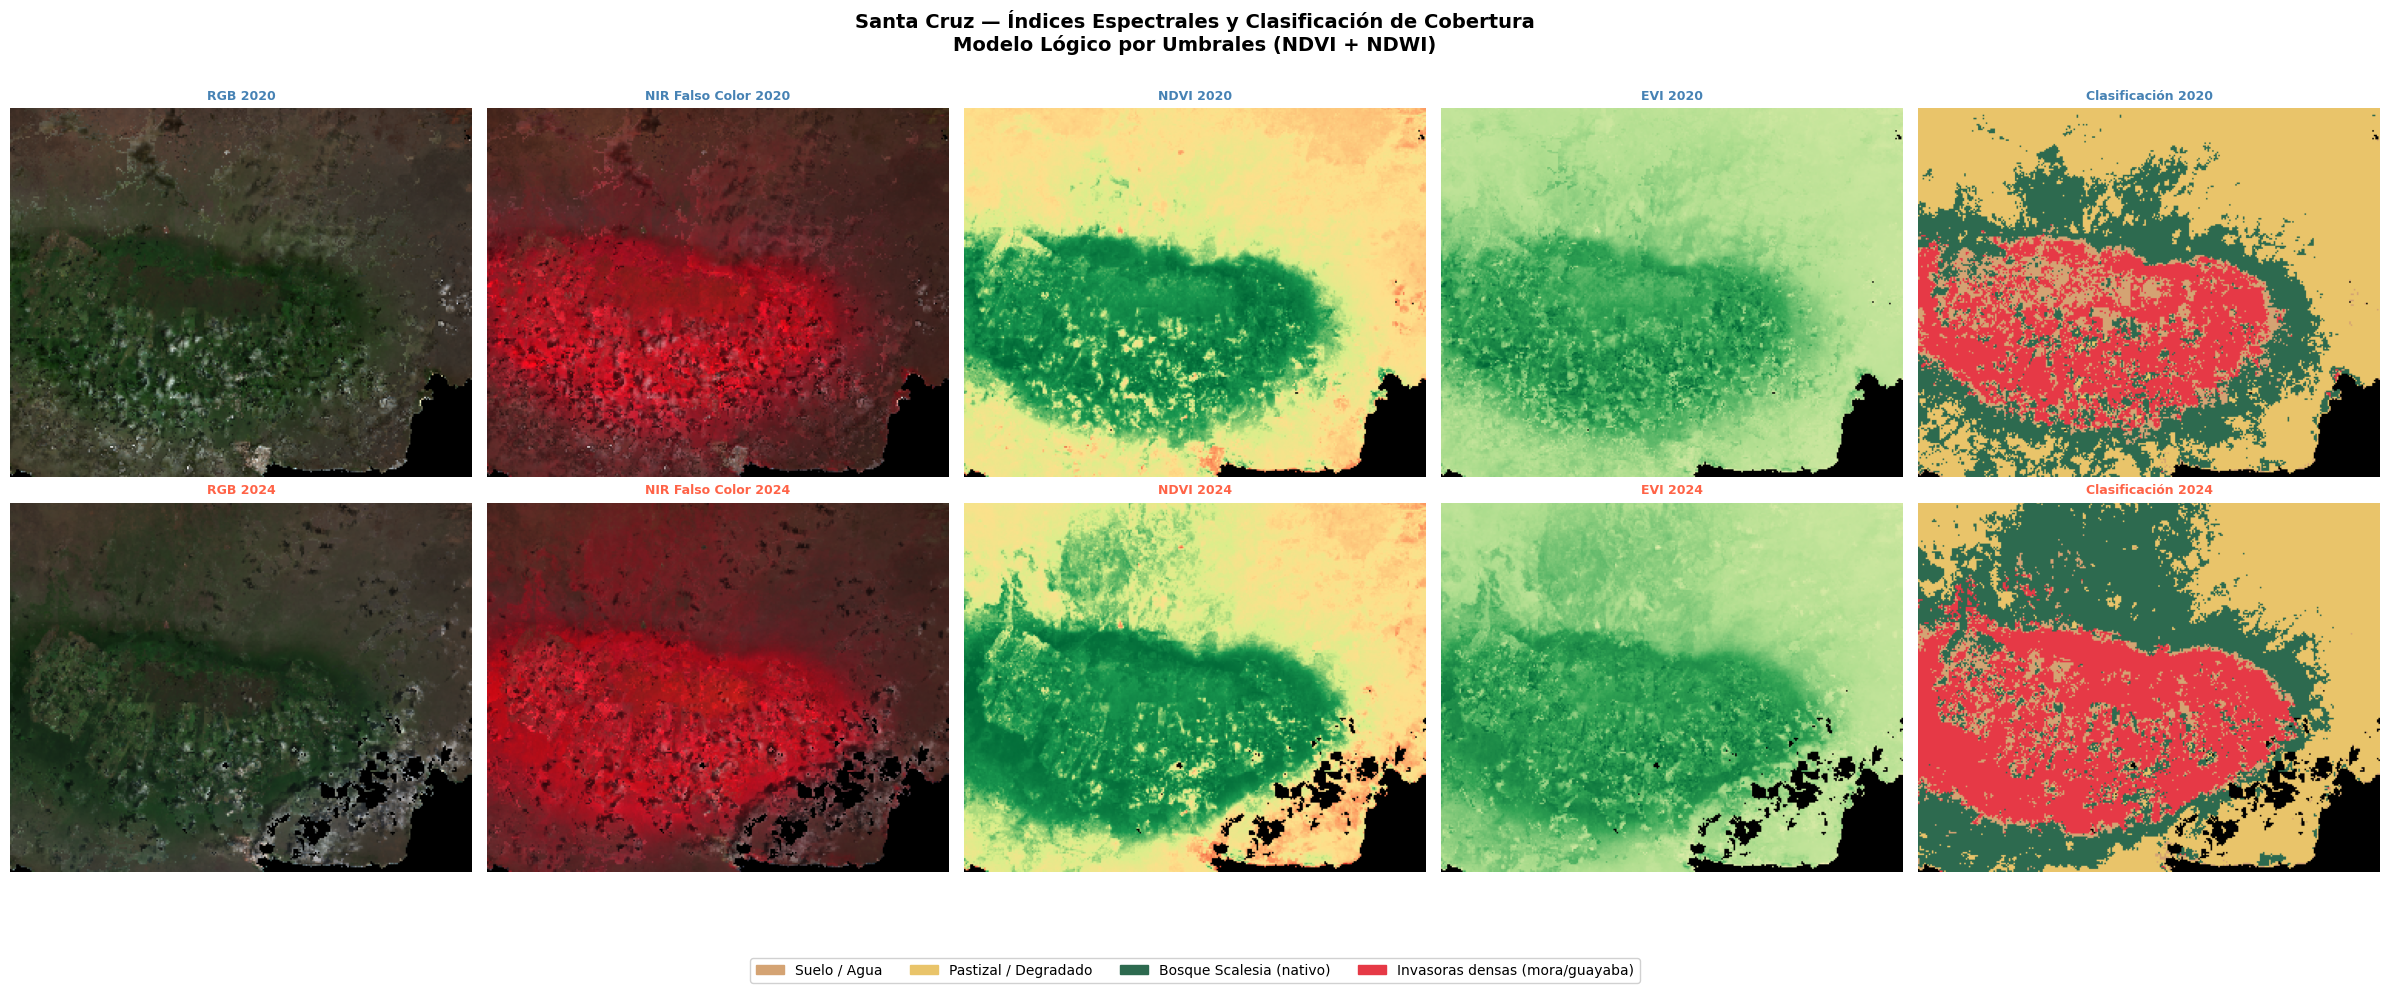

Modelo lógico visualizado: índices + clasificación 2020 vs 2024


In [9]:
# ── Visualizar índices y clasificación (modelo lógico) ────────────────────────
vis_ndvi_idx = {'min': -0.1, 'max': 0.9,
                'bands': ['NDVI'],
                'palette': ['#d73027','#fc8d59','#fee08b','#d9ef8b','#1a9850','#006837']}
vis_evi_idx  = {'min': -0.1, 'max': 0.8,
                'bands': ['EVI'],
                'palette': ['#fff7bc','#addd8e','#31a354','#006837']}
vis_clas     = {'min': 0, 'max': 3,
                'palette': ['#d4a373','#e9c46a','#2d6a4f','#e63946']}
vis_avance   = {'min': 0, 'max': 1, 'palette': ['#f0f0f0','#e63946']}

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle('Santa Cruz — Índices Espectrales y Clasificación de Cobertura\n'
             'Modelo Lógico por Umbrales (NDVI + NDWI)',
             fontsize=14, fontweight='bold')

celdas = [
    # Fila 1: período 2020
    (comp_2020,   vis_rgb,      'RGB 2020'),
    (comp_2020,   vis_nir,      'NIR Falso Color 2020'),
    (ndvi_2020,   vis_ndvi_idx, 'NDVI 2020'),
    (evi_2020,    vis_evi_idx,  'EVI 2020'),
    (clases_2020, vis_clas,     'Clasificación 2020'),
    # Fila 2: período 2024
    (comp_2024,   vis_rgb,      'RGB 2024'),
    (comp_2024,   vis_nir,      'NIR Falso Color 2024'),
    (ndvi_2024,   vis_ndvi_idx, 'NDVI 2024'),
    (evi_2024,    vis_evi_idx,  'EVI 2024'),
    (clases_2024, vis_clas,     'Clasificación 2024'),
]

for idx, (img_ee, vis, titulo) in enumerate(celdas):
    ax = axes[idx // 5][idx % 5]
    thumb = get_thumb(img_ee, vis)
    ax.imshow(thumb)
    color = 'steelblue' if idx < 5 else 'tomato'
    ax.set_title(titulo, fontsize=9, fontweight='bold', color=color)
    ax.axis('off')

# Leyenda clasificación
leyenda = [
    mpatches.Patch(color='#d4a373', label='Suelo / Agua'),
    mpatches.Patch(color='#e9c46a', label='Pastizal / Degradado'),
    mpatches.Patch(color='#2d6a4f', label='Bosque Scalesia (nativo)'),
    mpatches.Patch(color='#e63946', label='Invasoras densas (mora/guayaba)'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=4,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('galapagos_clasificacion_modelo_logico.png', dpi=150, bbox_inches='tight')
plt.show()
print('Modelo lógico visualizado: índices + clasificación 2020 vs 2024')

Entre 2020 y 2024, los composites muestran una distribución espacial de vegetación densa 
concentrada en las tierras altas del centro-norte de Santa Cruz. El NDVI revela un núcleo 
de vegetación de alta densidad (> 0.65) que en 2024 aparece más fragmentado en sus bordes 
respecto al período base de 2020, lo que es consistente con el avance de especies invasoras 
como mora y guayaba sobre el bosque de Scalesia. La clasificación por umbrales (NDVI + NDWI) 
permite distinguir cuatro clases de cobertura, aunque la separación entre Scalesia e invasoras 
requiere índices adicionales como RE_NDVI y NDWI foliar — limitación que motiva el uso de un 
modelo de clasificación supervisada en la siguiente sección.

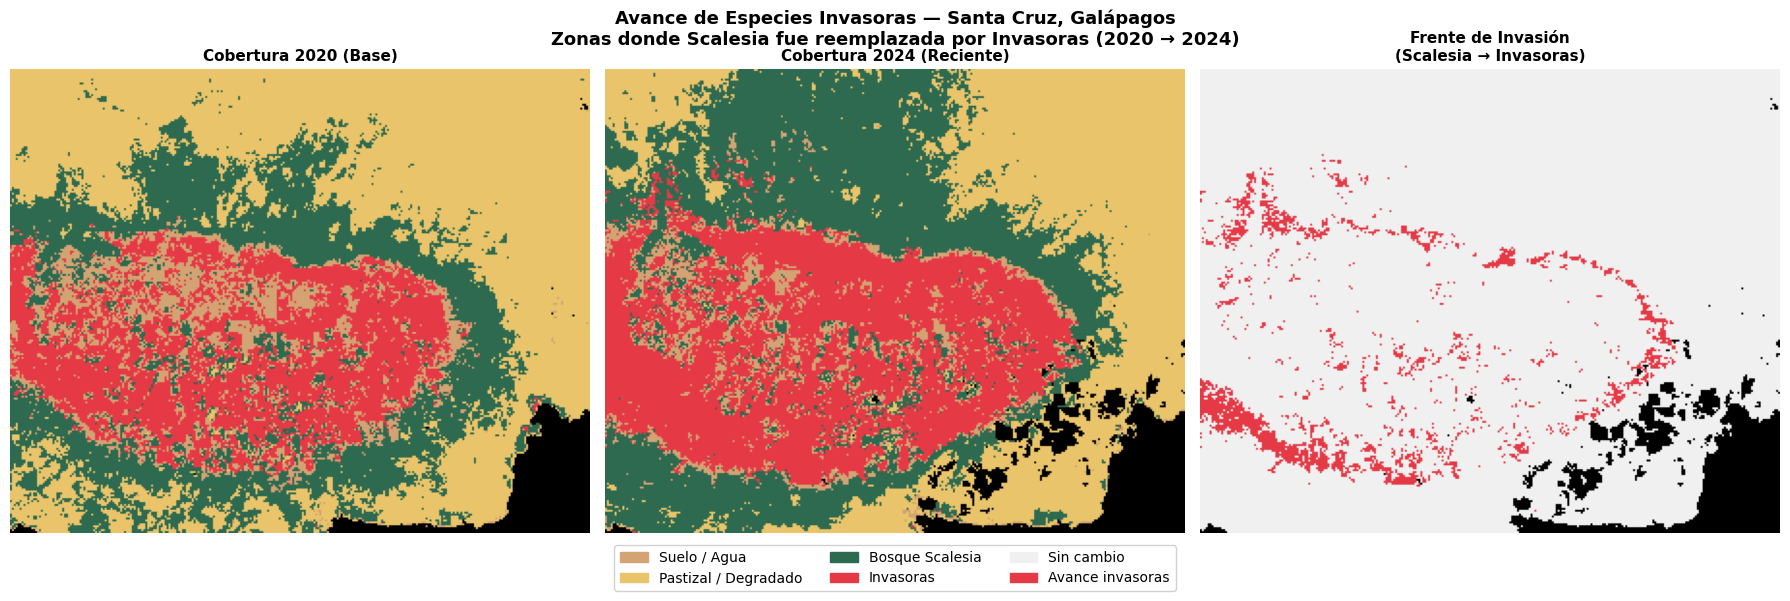

Mapa de frente de invasión generado: 2020 → 2024


In [10]:
# ── Mapa de avance de invasoras ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Avance de Especies Invasoras — Santa Cruz, Galápagos\n'
             'Zonas donde Scalesia fue reemplazada por Invasoras (2020 → 2024)',
             fontsize=13, fontweight='bold')

for ax, (img_ee, vis, titulo) in zip(axes, [
    (clases_2020,      vis_clas,    'Cobertura 2020 (Base)'),
    (clases_2024,      vis_clas,    'Cobertura 2024 (Reciente)'),
    (avance_invasoras, vis_avance,  'Frente de Invasión\n(Scalesia → Invasoras)'),
]):
    thumb = get_thumb(img_ee, vis)
    ax.imshow(thumb)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.axis('off')

leyenda2 = [
    mpatches.Patch(color='#d4a373', label='Suelo / Agua'),
    mpatches.Patch(color='#e9c46a', label='Pastizal / Degradado'),
    mpatches.Patch(color='#2d6a4f', label='Bosque Scalesia'),
    mpatches.Patch(color='#e63946', label='Invasoras'),
    mpatches.Patch(color='#f0f0f0', label='Sin cambio'),
    mpatches.Patch(color='#e63946', label='Avance invasoras'),
]
fig.legend(handles=leyenda2, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('galapagos_avance_invasoras.png', dpi=150, bbox_inches='tight')
plt.show()
print('Mapa de frente de invasión generado: 2020 → 2024')

In [11]:
# ── Estadísticas: cambio de cobertura entre 2020 y 2024 ──────────────────────
def stats_indice(img, banda, label):
    stats = img.select(banda).reduceRegion(
        reducer=ee.Reducer.mean().combine(
                 ee.Reducer.percentile([25, 75]), sharedInputs=True),
        geometry=santa_cruz,
        scale=10,          # resolución nativa Sentinel-2, no 500m
        maxPixels=1e9
    ).getInfo()
    mean = stats.get(f'{banda}_mean', float('nan'))
    p25  = stats.get(f'{banda}_p25',  float('nan'))
    p75  = stats.get(f'{banda}_p75',  float('nan'))
    print(f'  [{label}]  media={mean:.3f}  | P25={p25:.3f}  | P75={p75:.3f}')
    return mean

print('── NDVI ──────────────────────────────────────────────')
mean_ndvi_2020 = stats_indice(comp_2020, 'NDVI', '2020 base    ')
mean_ndvi_2024 = stats_indice(comp_2024, 'NDVI', '2024 reciente')
delta_ndvi = mean_ndvi_2024 - mean_ndvi_2020
print(f'  Δ NDVI (2024-2020) = {delta_ndvi:+.3f}  → {"AUMENTO" if delta_ndvi > 0 else "DESCENSO"} de vegetación densa')

print('\n── NDWI (humedad foliar) ─────────────────────────────')
mean_ndwi_2020 = stats_indice(comp_2020, 'NDWI', '2020 base    ')
mean_ndwi_2024 = stats_indice(comp_2024, 'NDWI', '2024 reciente')
delta_ndwi = mean_ndwi_2024 - mean_ndwi_2020
print(f'  Δ NDWI (2024-2020) = {delta_ndwi:+.3f}  → {"AUMENTO" if delta_ndwi > 0 else "DESCENSO"} de humedad foliar (indicador de invasoras)')

print('\n── Interpretación ────────────────────────────────────')
print('  NDVI > 0.65 + NDWI alto  → Probable invasoras (mora/guayaba)')
print('  NDVI 0.40–0.65 + NDWI bajo → Bosque nativo Scalesia')
print('  NDVI 0.10–0.40            → Pastizal o zona degradada')
print('  NDVI < 0.10               → Suelo desnudo, roca volcánica o agua')

── NDVI ──────────────────────────────────────────────
  [2020 base    ]  media=0.500  | P25=0.324  | P75=0.691
  [2024 reciente]  media=0.542  | P25=0.363  | P75=0.731
  Δ NDVI (2024-2020) = +0.042  → AUMENTO de vegetación densa

── NDWI (humedad foliar) ─────────────────────────────
  [2020 base    ]  media=0.021  | P25=-0.137  | P75=0.176
  [2024 reciente]  media=0.079  | P25=-0.090  | P75=0.238
  Δ NDWI (2024-2020) = +0.058  → AUMENTO de humedad foliar (indicador de invasoras)

── Interpretación ────────────────────────────────────
  NDVI > 0.65 + NDWI alto  → Probable invasoras (mora/guayaba)
  NDVI 0.40–0.65 + NDWI bajo → Bosque nativo Scalesia
  NDVI 0.10–0.40            → Pastizal o zona degradada
  NDVI < 0.10               → Suelo desnudo, roca volcánica o agua


## Interpretación de Resultados Estadísticos

### NDVI
El NDVI medio aumentó de 0.500 en 2020 a 0.542 en 2024 (Δ = +0.042), lo que indica
un incremento general de la densidad vegetal en Santa Cruz. El percentil 75 pasó de
0.691 a 0.731, sugiriendo que las zonas de vegetación más densa se han vuelto aún
más densas — patrón consistente con el crecimiento de especies invasoras de dosel
continuo como mora y guayaba.

### NDWI (humedad foliar)
El incremento más significativo está en el NDWI: de 0.021 a 0.079 (Δ = +0.058).
Este aumento de humedad foliar es el indicador más directo de avance de invasoras,
ya que mora y guayaba mantienen mayor contenido de agua en sus hojas que Scalesia
durante la época seca. El desplazamiento del P25 de -0.137 a -0.090 indica además
que incluso las zonas de menor actividad vegetal han ganado humedad foliar.

### Conclusión estadística
La combinación de NDVI creciente + NDWI creciente entre 2020 y 2024 es consistente
con el avance de especies invasoras sobre el bosque nativo. Estos resultados validan
el uso de ambos índices como variables discriminantes en el modelo de clasificación
de la siguiente sección.

## 5. Mapa Interactivo

In [ ]:
# ── Mapa interactivo con geemap ───────────────────────────────────────────────
Map = geemap.Map(center=[-0.65, -90.32], zoom=11)

Map.addLayer(comp_2020,        vis_rgb,      'RGB 2020')
Map.addLayer(comp_2024,        vis_rgb,      'RGB 2024')
Map.addLayer(ndvi_2020,        vis_ndvi_idx, 'NDVI 2020')
Map.addLayer(ndvi_2024,        vis_ndvi_idx, 'NDVI 2024')
Map.addLayer(evi_2020,         vis_evi_idx,  'EVI 2020')
Map.addLayer(evi_2024,         vis_evi_idx,  'EVI 2024')
Map.addLayer(clases_2020,      vis_clas,     'Clasificación 2020')
Map.addLayer(clases_2024,      vis_clas,     'Clasificación 2024')
Map.addLayer(avance_invasoras, vis_avance,   'Frente de Invasión (2020→2024)')

Map.addLayerControl()
Map